In [2]:
import pandas as pd 
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv(r'C:\Users\YUSEF\Desktop\Data Analysis Project\Chicago_Trips\Dataset\Sep_Trips.csv')
df

,Trip_ID,Taxi_ID,Trip_Start_Timestamp,Trip_End_Timestamp,Trip_Seconds,Trip_Kilometers,Pickup_Community_Area,Dropoff_Community_Area,Fare,Tips,Tolls,Extras,Trip_Total,Payment_Type,Company,Pickup_Centroid_Latitude,Pickup_Centroid_Longitude,Dropoff_Centroid_Latitude,Dropoff_Centroid_Longitude
0,e7769b94d4626099eac66479ca6f3440ade9ddb8,72920f6ebc5830d39039323cf78a316085444eb8f8b272...,2020-09-30 22:15:00.0000000,2020-09-30 22:30:00.0000000,840,4.67,8,7,11.75,0.0,0.0,0.0,11.75,Cash,Taxi Affiliation Services,41.899601,-87.633308,41.922688,-87.649490
1,e2af0b1cdb78ee5666cce4338f78ac303efc3574,362dbe26e2730f8c392d5dc3e48fe2dfdebfa8e15dd52f...,2020-09-30 22:15:00.0000000,2020-09-30 22:30:00.0000000,913,18.22,49,32,29.25,0.0,0.0,0.0,29.25,Cash,Flash Cab,41.706589,-87.623367,41.878864,-87.625191
2,cc0cde7795710f36abaa74cf8635e72262a9d50c,362dbe26e2730f8c392d5dc3e48fe2dfdebfa8e15dd52f...,2020-09-30 22:15:00.0000000,2020-09-30 22:30:00.0000000,943,18.22,49,32,29.25,0.0,0.0,0.0,29.25,Cash,Flash Cab,41.706589,-87.623367,41.878864,-87.625191
3,bb38495ee30fa57128bac655f723479c1552b15d,bd17c98f1180b95a8fb96443859794525f51e99ef77132...,2020-09-30 22:15:00.0000000,2020-09-30 22:30:00.0000000,860,5.91,69,71,12.75,0.0,0.0,0.0,12.75,Prcard,Flash Cab,41.763248,-87.616135,41.744205,-87.656303
4,a521878a6607daf1e10ccb4fb4dca1c6ebbf55d1,0ea15dafe7094cba8dd92167a79db0f7366aaf964f8edb...,2020-09-30 22:15:00.0000000,2020-09-30 22:15:00.0000000,293,0.80,8,8,5.00,0.0,0.0,0.0,5.00,Cash,Medallion Leasin,41.899601,-87.633308,41.899601,-87.633308
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140874,272df3fb2170d24df873afc4874a59ad97f5e040,3c5b339b7effe478dbe57484799491a14048c122c3915c...,2020-09-01 09:15:00.0000000,2020-09-01 09:45:00.0000000,1800,15.77,38,49,27.25,0.0,0.0,0.0,27.25,Unknown,Taxi Affiliation Services,41.812950,-87.617859,41.706589,-87.623367
140875,24838ff3075e27103263e2b9a8214529f4b9af6f,bbdec1f9949f4e13be32d6d0038763a29f09ef18534115...,2020-09-01 09:15:00.0000000,2020-09-01 09:30:00.0000000,360,2.41,13,6,7.00,0.0,0.0,0.0,7.00,Cash,Globe Taxi,41.983635,-87.723579,41.944225,-87.655998
140876,1e9ea17fbd14454848f3f769695570e1201995ef,c797f1560410b9db343567ea7c8e4095f66ceb65800fa4...,2020-09-01 09:15:00.0000000,2020-09-01 09:15:00.0000000,631,6.29,77,6,12.50,0.0,0.0,0.0,12.50,Prcard,Flash Cab,41.986713,-87.663414,41.944225,-87.655998
140877,1cbe0a6aabdcbed7ece64740cea83245a653884b,5445efb47d0f94d15a8b2171fb9ba042e80b51ba6fb25f...,2020-09-01 09:15:00.0000000,2020-09-01 09:30:00.0000000,763,6.44,6,8,13.50,0.0,0.0,0.0,13.50,Cash,Flash Cab,41.944225,-87.655998,41.899601,-87.633308


<Axes: >

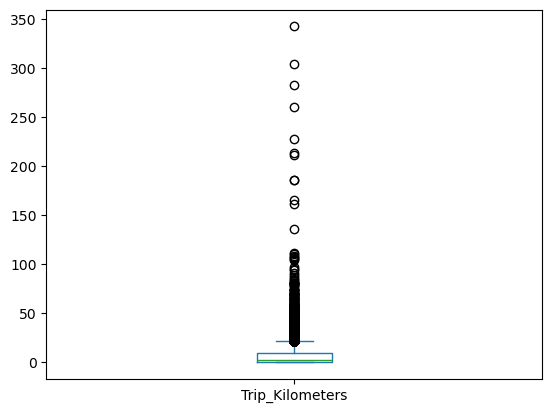

In [ ]:
df['Trip_Seconds'].plot(kind='box')

In [5]:
df['Trip_Kilometers'].sample(5)

40853      1.77
44311      1.22
132291    16.58
85097      0.00
71073     13.24
Name: Trip_Kilometers, dtype: float64

In [6]:
df['Trip_Kilometers'].agg(['mean','min','max','median'])

mean        6.250383
min         0.000000
max       342.150000
median      2.670000
Name: Trip_Kilometers, dtype: float64

In [12]:
q3 = df['Trip_Kilometers'].quantile(.75)
q1 = df['Trip_Kilometers'].quantile(.25)
iqr =q3-q1

In [13]:
upper_bound = (1.5*iqr) + q3    
lower_bound = (1.5*iqr) - q1

In [22]:
df_no_outliers = df[(df['Trip_Kilometers'] >= lower_bound) & (df['Trip_Kilometers'] <=upper_bound)]
df_no_outliers['Trip_Kilometers'].agg(['min','max','mean','median'])

min       11.910000
max       21.970000
mean      16.369267
median    16.290000
Name: Trip_Kilometers, dtype: float64

<Axes: >

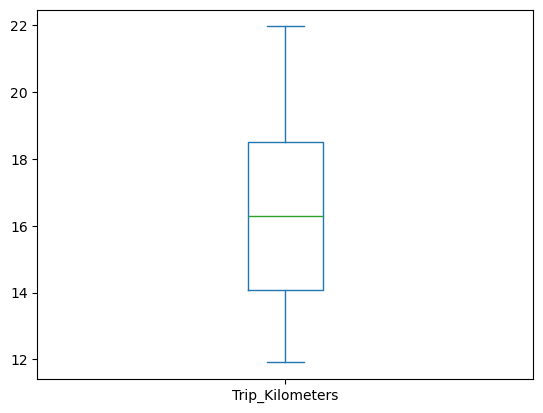

In [19]:
df_no_outliers['Trip_Kilometers'].plot(kind='box')

In [20]:
print(q1,q3)

0.8 9.27


In [ ]:
# ! greater than 9.27 long and greater than 21.97 very long
# ! smaller than 11.9 is small and smaller 0.8 is very small

In [62]:
q3 = df['Trip_Kilometers'].quantile(.75)
q1 = df['Trip_Kilometers'].quantile(.25)
iqr =q3-q1
upper_bound = (1.5*iqr) + q3    
lower_bound = (1.5*iqr) - q1
df_no_outliers = df[(df['Trip_Kilometers'] >= lower_bound) & (df['Trip_Kilometers'] <=upper_bound)]

q1_2 = df_no_outliers['Trip_Kilometers'].quantile(0.25)
q3_2 = df_no_outliers['Trip_Kilometers'].quantile(0.75)
 
df_no_outliers['Trip_Kilometers'].describe()

count    20027.000000
mean        16.369267
std          2.708435
min         11.910000
25%         14.070000
50%         16.290000
75%         18.510000
max         21.970000
Name: Trip_Kilometers, dtype: float64

In [59]:
q3_t = df['Trip_Seconds'].quantile(.75)
q1_t = df['Trip_Seconds'].quantile(.25)
iqr_t =q3_t-q1_t
upper_bound_t = (1.5*iqr_t) + q3_t    
lower_bound_t = (1.5*iqr_t) - q1_t
df_no_outliers = df[(df['Trip_Seconds'] >= lower_bound_t) & (df['Trip_Seconds'] <=upper_bound_t)]

q1_2_t = df_no_outliers['Trip_Seconds'].quantile(0.25)
q3_2_t = df_no_outliers['Trip_Seconds'].quantile(0.75)
 

print('lower than',df_no_outliers['Trip_Seconds'].min(),'Very Low',',lower than',q1_2_t,'low','greater than',q1_2_t,'mid and , greater than',q3_2_t ,'long','mid and, greater than',df_no_outliers['Trip_Seconds'].max() ,'Very Long')
df_no_outliers['Trip_Seconds'].describe()

lower than 969 Very Low ,lower than 1200.0 low greater than 1200.0 mid and , greater than 1800.0 long mid and, greater than 2575 Very Long


count    42774.000000
mean      1526.300159
std        396.768708
min        969.000000
25%       1200.000000
50%       1440.000000
75%       1800.000000
max       2575.000000
Name: Trip_Seconds, dtype: float64

In [57]:
q3_t = df['Trip_Total'].quantile(.75)
q1_t = df['Trip_Total'].quantile(.25)
iqr_t =q3_t-q1_t
upper_bound_t = (1.5*iqr_t) + q3_t    
lower_bound_t = (1.5*iqr_t) - q1_t
df_no_outliers = df[(df['Trip_Total'] >= lower_bound_t) & (df['Trip_Total'] <=upper_bound_t)]
 

print('lower than',df_no_outliers['Trip_Seconds'].min(),'Very Low',',lower than',q1_2_t,'low','greater than',q1_2_t,'mid and , greater than',q3_2_t ,'long','mid and, greater than',df_no_outliers['Trip_Seconds'].max() ,'Very Long')
# df_no_outliers['Trip_Seconds'].max() #85635
# df['Trip_Seconds'].max() #85340

lower than 0 Very Low ,lower than 20.75 low greater than 20.75 mid and , greater than 30.975 long mid and, greater than 85635 Very Long


In [56]:
df_no_outliers['Trip_Total'].describe()

count    41607.000000
mean        26.841404
std          7.181216
min         16.440000
25%         20.750000
50%         26.250000
75%         30.975000
max         45.830000
Name: Trip_Total, dtype: float64

In [ ]:


print('lower than () low and lower than () very low and  () is Unknown')